## Interpretación del modelo y plan de experimentos

### By:
Bryan Escobar Restrepo

### Date:
2026-08-21

### Description:

Séptima etapa del proyecto (`6-interpretation`). Toma el modelo seleccionado en
`06.Seleccion-de-modelo-AutoML` (Extra Trees, MAE 0.0476 en test) y responde a lo que las
métricas no dicen, siguiendo los pasos de
<https://joserzapata.github.io/post/ciencia-datos-proyecto-python/7-model_interpretation/>:

- **Cómo decide** el modelo: qué atributos usa y de qué forma.
- **Qué tipo de errores** comete y **a qué se deben**.
- **Qué consecuencias** tienen esas malas predicciones para el usuario del producto.

El objetivo final es concreto: salir de aquí con un **listado priorizado de pruebas y
experimentos para la siguiente iteración**, justificado por evidencia y no por intuición.

Un modelo con un MAE aceptable puede seguir siendo inservible si se equivoca
sistemáticamente con un tipo de aspirante, o si sus errores empujan siempre en la
dirección más costosa. Eso es lo que se examina aquí.

## 📚 Import  libraries

In [1]:
# base libraries for data science
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, learning_curve, train_test_split
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)

print(f"pandas {pd.__version__}   shap {shap.__version__}")

pandas 3.0.5   shap 0.52.0


## ⚙️ Configuración

In [2]:
def buscar_raiz_proyecto() -> Path:
    """Sube por el árbol de directorios hasta encontrar la raíz del repositorio."""
    marcadores = (".git", "pyproject.toml")
    actual = Path.cwd().resolve()
    for candidato in (actual, *actual.parents):
        if any((candidato / marcador).exists() for marcador in marcadores):
            return candidato
    return actual


RAIZ = buscar_raiz_proyecto()
sys.path.insert(0, str(RAIZ / "src"))

from data.transformaciones import a_tipos_sklearn  # noqa: E402

ARCHIVO_DATOS = RAIZ / "data" / "02_intermediate" / "admisiones_type_fixed.parquet"
ARCHIVO_MODELO = RAIZ / "data" / "06_models" / "modelo_final_automl.joblib"
ARCHIVO_MODELO_BASE = RAIZ / "data" / "06_models" / "modelo_base_heuristica.joblib"
DIR_REPORTES = RAIZ / "data" / "08_reporting"
DIR_REPORTES.mkdir(parents=True, exist_ok=True)

TARGET = "chance_of_admit"
PROPORCION_TEST = 0.25
SEMILLA = 42

sns.set_theme(style="whitegrid", palette="deep")
print(f"Modelo a interpretar: {ARCHIVO_MODELO.relative_to(RAIZ)}")

Modelo a interpretar: data/06_models/modelo_final_automl.joblib


## 💾 Cargar los datos y el modelo entregado

Se reproduce la misma partición de las etapas anteriores y se carga el artefacto
`.joblib` **tal cual quedó versionado**, sin reentrenar. Interpretar un modelo distinto
del que se va a desplegar no serviría de nada, así que lo primero es comprobar que el
artefacto reproduce las métricas registradas.

In [3]:
df = pd.read_parquet(ARCHIVO_DATOS)
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(float)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=PROPORCION_TEST, random_state=SEMILLA
)

modelo = joblib.load(ARCHIVO_MODELO)
preprocesador = modelo.named_steps["preparacion"]
estimador = modelo.named_steps["modelo"]

prediccion = pd.Series(modelo.predict(X_test), index=X_test.index, name="prediccion")
residuos = (y_test - prediccion).rename("residuo")
errores = residuos.abs().rename("error_absoluto")

MAE_REGISTRADO = 0.0476
mae_actual = mean_absolute_error(y_test, prediccion)
if not np.isclose(mae_actual, MAE_REGISTRADO, atol=1e-4):
    raise ValueError(f"El artefacto no reproduce el MAE registrado: {mae_actual:.4f}")

print(f"Modelo    : {type(estimador).__name__} con {estimador.n_estimators} arboles")
print(f"MAE (test): {mae_actual:.4f}   R2: {r2_score(y_test, prediccion):.4f}")
print("El artefacto reproduce las metricas registradas en 06.")

Modelo    : ExtraTreesRegressor con 60 arboles
MAE (test): 0.0476   R2: 0.8048
El artefacto reproduce las metricas registradas en 06.


## 🔎 Identificar los atributos más importantes

Se usan **tres métodos distintos**, porque cada uno mide algo diferente y compararlos
revela más que cualquiera por separado:

| Método | Qué mide | Punto débil conocido |
|---|---|---|
| Impureza (*Gini*) | cuánto reduce la varianza cada atributo al dividir los árboles | favorece atributos con muchos valores distintos; se calcula sobre **entrenamiento** |
| Permutación | cuánto empeora el modelo al desordenar la columna | con atributos correlacionados **reparte la importancia hacia abajo**: el modelo compensa con el atributo gemelo |
| SHAP | cuánto aporta cada atributo a **cada predicción concreta**, con base en teoría de juegos | costoso en modelos grandes; aquí es viable |

In [4]:
X_train_preparado = preprocesador.transform(X_train)
X_test_preparado = preprocesador.transform(X_test)
ATRIBUTOS = list(X_test_preparado.columns)

# 1. impureza (viene calculada del entrenamiento)
importancia_impureza = pd.Series(estimador.feature_importances_, index=ATRIBUTOS)

# 2. permutacion sobre el conjunto de prueba
resultado_permutacion = permutation_importance(
    modelo, X_test, y_test, n_repeats=30, random_state=SEMILLA, scoring="neg_mean_absolute_error"
)
importancia_permutacion = pd.Series(resultado_permutacion.importances_mean, index=X_test.columns)

# 3. SHAP sobre el conjunto de prueba
explicador = shap.TreeExplainer(estimador)
valores_shap = explicador.shap_values(X_test_preparado)
valor_base = float(np.ravel(explicador.expected_value)[0])
importancia_shap = pd.Series(np.abs(valores_shap).mean(axis=0), index=ATRIBUTOS)

comparacion_importancias = pd.DataFrame(
    {
        "impureza_%": 100 * importancia_impureza / importancia_impureza.sum(),
        "permutacion_%": 100
        * importancia_permutacion.clip(lower=0)
        / importancia_permutacion.clip(lower=0).sum(),
        "shap_%": 100 * importancia_shap / importancia_shap.sum(),
    }
).sort_values("shap_%", ascending=False)

print(
    f"Valor base de SHAP: {valor_base:.4f}   (media del target en entrenamiento: {y_train.mean():.4f})"
)
comparacion_importancias.round(1)

Valor base de SHAP: 0.7221   (media del target en entrenamiento: 0.7221)


,impureza_%,permutacion_%,shap_%
cgpa,31.2,43.5,30.0
gre_score,20.0,20.5,18.8
toefl_score,16.0,10.6,14.9
research,8.3,8.4,13.8
university_rating,9.9,7.7,9.4
lor,6.3,4.6,7.0
sop,8.2,4.6,6.0


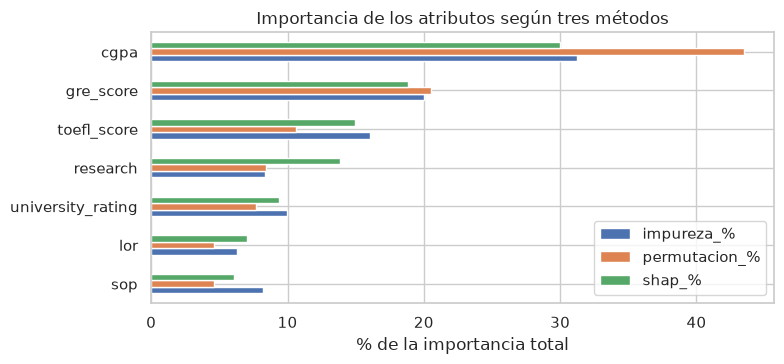

In [5]:
_, ax = plt.subplots(figsize=(8, 3.8))
comparacion_importancias.sort_values("shap_%").plot(kind="barh", ax=ax)
ax.set_xlabel("% de la importancia total")
ax.set_title("Importancia de los atributos según tres métodos")
plt.tight_layout()
plt.show()

**Los tres métodos coinciden en el orden y discrepan en el reparto.**

El orden es idéntico en los tres: `cgpa` domina, seguido de `gre_score` y `toefl_score`,
luego `research` y `university_rating`, y al final `lor` y `sop`. Coincide con lo que ya
indicaban la correlación de `03.2` y los modelos de una sola variable de `05`.

Donde difieren es en **cuánto** concentran:

| Atributo | Impureza | Permutación | SHAP |
|---|---|---|---|
| `cgpa` | 31.2 % | **43.5 %** | 30.0 % |
| `gre_score` | 20.0 % | 20.5 % | 18.8 % |
| `toefl_score` | 16.0 % | 10.6 % | 14.9 % |
| `research` | 8.3 % | 8.4 % | **13.8 %** |
| `university_rating` | 9.9 % | 7.7 % | 9.4 % |
| `lor` | 6.3 % | 4.6 % | 7.0 % |
| `sop` | 8.2 % | 4.6 % | 6.0 % |

La permutación carga el 43.5 % sobre `cgpa` mientras SHAP reparte más. No se contradicen,
**miden cosas distintas**:

- La **permutación** pregunta *"si desordeno esta columna, ¿cuánto empeora el modelo?"*.
  Cuando varios atributos comparten información —y aquí `cgpa`, `gre_score` y
  `toefl_score` correlacionan entre 0.83 y 0.85— desordenar uno secundario apenas duele,
  porque el modelo **recupera la información por otro camino**. Mide *información única*.
- **SHAP** pregunta *"¿cuánto movió esta variable esta predicción concreta?"*, y reparte el
  crédito entre los atributos correlacionados en vez de dárselo todo a uno.

El contraste con `05-models` lo deja claro: allí la misma permutación, aplicada a la
**`Ridge`**, daba a `cgpa` un 75 % del total y a `research` un 2 %. El modelo de árboles
usa las variables de forma mucho más repartida, y por eso gana ese 4 % de MAE al modelo
lineal.

La consecuencia práctica es sobre `research`: **es informativa pero redundante**. Para
explicarle a un aspirante por qué se le dio ese número, cuenta (13.8 % según SHAP); para
decidir si vale la pena invertir en recogerla como dato nuevo, cuenta menos.

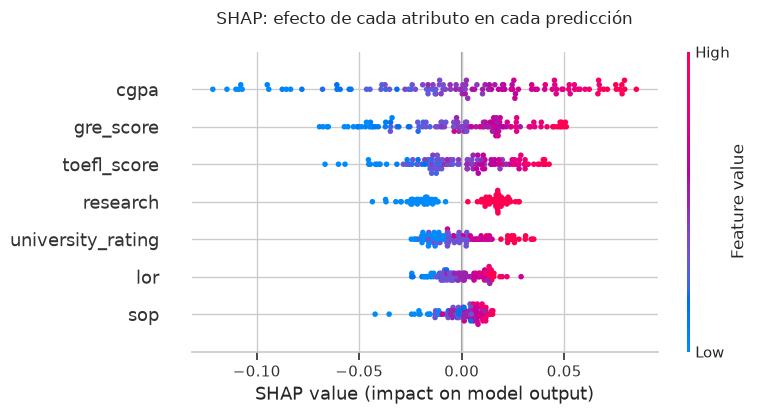

In [6]:
shap.summary_plot(valores_shap, X_test_preparado, plot_type="dot", show=False)
plt.title("SHAP: efecto de cada atributo en cada predicción", pad=20)
plt.tight_layout()
plt.show()

Cada punto es un aspirante del conjunto de prueba. El eje horizontal es cuánto empujó ese
atributo su predicción; el color, si el valor del atributo era alto (rojo) o bajo (azul).

El patrón es limpio y **es el que debería tener un modelo sensato**: en todos los
atributos los valores altos (rojo) empujan hacia la derecha y los bajos hacia la
izquierda. No hay ninguna variable con efecto invertido, que sería la primera señal de un
problema de codificación o de una correlación espuria aprendida.

La dispersión de `cgpa` es la más ancha (de −0.15 a +0.15 aproximadamente): es el atributo
que puede cambiar más una predicción individual.

## 📐 Cómo usa el modelo cada atributo

La importancia dice *cuánto* pesa un atributo, no *de qué forma*. Para eso están los
gráficos de dependencia: muestran la relación aprendida entre el valor del atributo y su
efecto sobre la predicción.

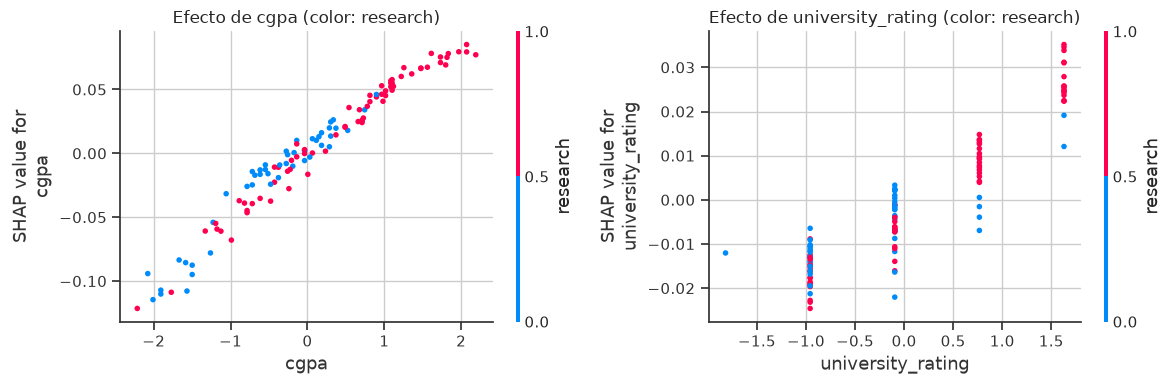

In [7]:
_, axes = plt.subplots(1, 2, figsize=(12, 4))
shap.dependence_plot(
    "cgpa", valores_shap, X_test_preparado, interaction_index="research", ax=axes[0], show=False
)
axes[0].set_title("Efecto de cgpa (color: research)")
shap.dependence_plot(
    "university_rating",
    valores_shap,
    X_test_preparado,
    interaction_index="research",
    ax=axes[1],
    show=False,
)
axes[1].set_title("Efecto de university_rating (color: research)")
plt.tight_layout()
plt.show()

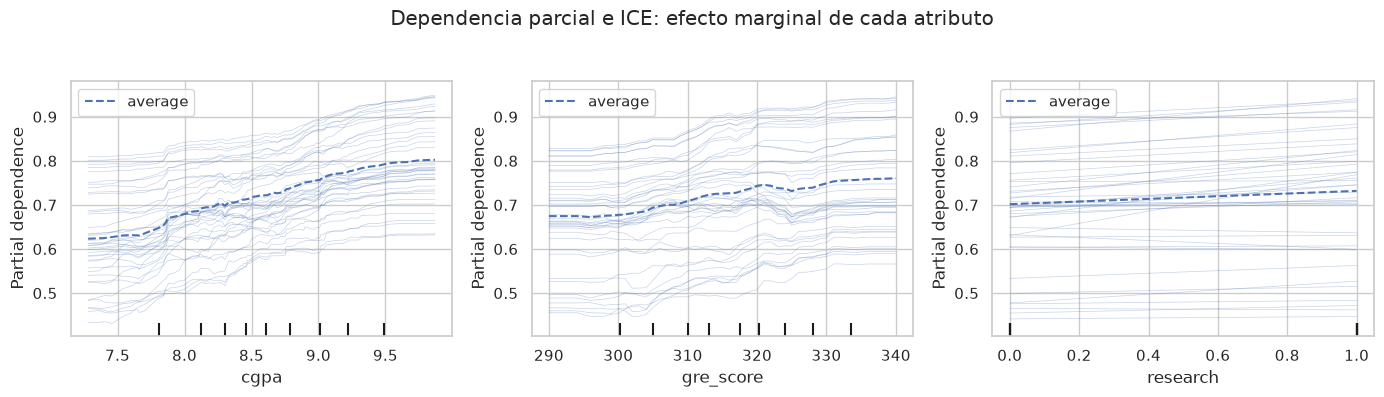

In [8]:
# PartialDependenceDisplay rechaza columnas enteras: se le pasa la version en float,
# que es justo lo que el primer paso del pipeline produce internamente
X_test_numerico = a_tipos_sklearn(X_test)

_, ax = plt.subplots(1, 3, figsize=(14, 3.8))
PartialDependenceDisplay.from_estimator(
    modelo,
    X_test_numerico,
    features=["cgpa", "gre_score", "research"],
    kind="both",
    subsample=40,
    random_state=SEMILLA,
    ax=ax,
)
plt.suptitle("Dependencia parcial e ICE: efecto marginal de cada atributo", y=1.04)
plt.tight_layout()
plt.show()

Las curvas de dependencia parcial (la línea gruesa) muestran una relación **monótona
creciente y casi lineal** en `cgpa` y `gre_score`, con dos matices importantes:

1. **Se aplanan en los extremos.** Por debajo de `cgpa` ≈ 7.5 y por encima de ≈ 9.5 la
   curva deja de subir. No es que el modelo haya aprendido que ahí el promedio deja de
   importar: es que **casi no tiene datos** en esos rangos, y un árbol no extrapola —
   devuelve el promedio de las hojas que conoce.
2. **Las líneas finas (ICE) son casi paralelas.** Cada línea es un aspirante concreto. Que
   sean paralelas significa que el efecto de subir el `cgpa` es parecido para todos, es
   decir, **hay pocas interacciones fuertes**. El modelo se comporta casi como un modelo
   aditivo, lo que explica por qué la `Ridge` de `04` se quedaba a solo 0.0018 de MAE.

El aplanamiento del primer punto es la raíz de un problema que aparecerá en el análisis de
errores: el modelo **no puede predecir valores bajos**.

## 🧑 Interpretación de predicciones individuales

Un producto que aconseja a personas tiene que poder explicar **una** predicción, no solo
el comportamiento medio. El gráfico de cascada descompone una predicción concreta: parte
del valor base (la media del entrenamiento, 0.722) y suma la contribución de cada
atributo hasta llegar al valor predicho.

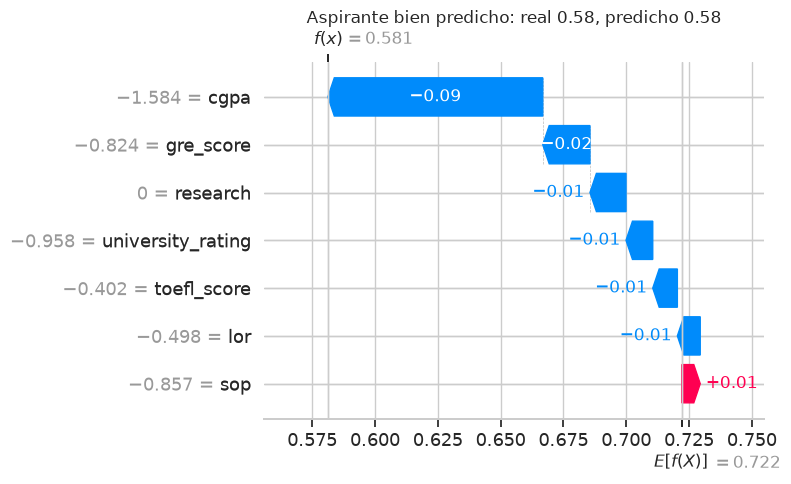

,gre_score,toefl_score,university_rating,sop,lor,cgpa,research
290,307,105,2,2.5,3.0,7.65,False


In [9]:
indice_mejor = errores.idxmin()
posicion_mejor = X_test.index.get_loc(indice_mejor)

explicacion = shap.Explanation(
    values=valores_shap[posicion_mejor],
    base_values=valor_base,
    data=X_test_preparado.iloc[posicion_mejor].to_numpy(),
    feature_names=ATRIBUTOS,
)
shap.plots.waterfall(explicacion, show=False)
plt.title(
    f"Aspirante bien predicho: real {y_test.loc[indice_mejor]:.2f}, predicho {prediccion.loc[indice_mejor]:.2f}"
)
plt.tight_layout()
plt.show()

X_test.loc[[indice_mejor]]

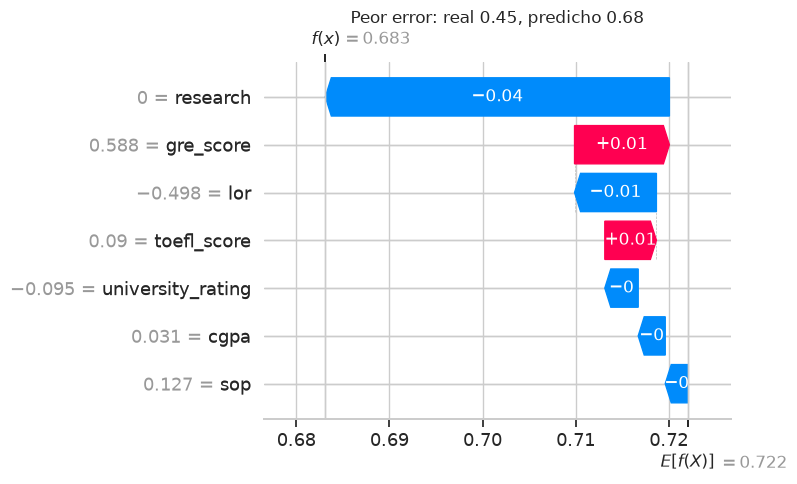

,gre_score,toefl_score,university_rating,sop,lor,cgpa,research
9,323,108,3,3.5,3.0,8.6,False


In [10]:
indice_peor = errores.idxmax()
posicion_peor = X_test.index.get_loc(indice_peor)

explicacion_peor = shap.Explanation(
    values=valores_shap[posicion_peor],
    base_values=valor_base,
    data=X_test_preparado.iloc[posicion_peor].to_numpy(),
    feature_names=ATRIBUTOS,
)
shap.plots.waterfall(explicacion_peor, show=False)
plt.title(
    f"Peor error: real {y_test.loc[indice_peor]:.2f}, predicho {prediccion.loc[indice_peor]:.2f}"
)
plt.tight_layout()
plt.show()

X_test.loc[[indice_peor]]

El segundo caso es el error más grande del conjunto de prueba y merece atención: un
aspirante con GRE 323, TOEFL 108, `cgpa` 8.6 y universidad de rating 3 — **un perfil
medio-alto por todos lados**. El modelo predice 0.68, que es exactamente lo que ese perfil
sugiere; el valor real es 0.45.

No hay nada que el modelo pudiera haber hecho distinto: **con esos siete números, 0.68 es
la respuesta razonable**. El error no está en el modelo, está en que el target de esa fila
no es coherente con su perfil. Esta observación se cuantifica más abajo.

## 📈 Curva de aprendizaje y escalabilidad del modelo final

Se repite el análisis de `05` y `06` sobre el modelo entregado, para dejarlo documentado
junto al resto de su ficha.

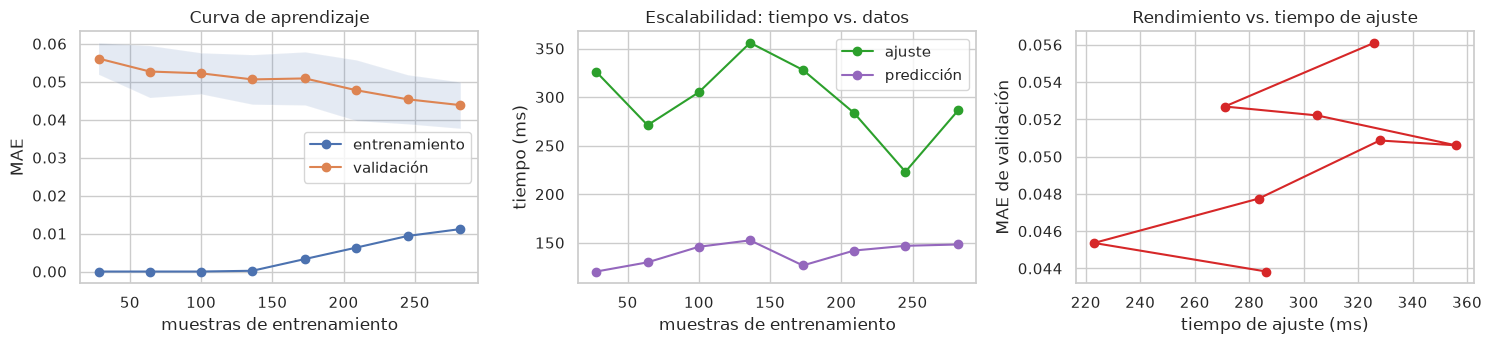

,MAE_train,MAE_validacion,brecha,tiempo_fit_ms
muestras,,,,
28,0.0000,0.0561,0.0561,325.9412
64,0.0000,0.0527,0.0527,271.0223
100,0.0000,0.0522,0.0522,304.9661
136,0.0002,0.0506,0.0504,355.9093
173,0.0033,0.0509,0.0476,327.9579
209,0.0063,0.0477,0.0414,283.5416
245,0.0094,0.0454,0.0360,223.0542
282,0.0112,0.0438,0.0327,286.3076


In [11]:
TALLAS = np.linspace(0.1, 1.0, 8)
tallas, puntaje_train, puntaje_validacion, tiempos_fit, tiempos_score = learning_curve(
    modelo,
    X_train,
    y_train,
    train_sizes=TALLAS,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEMILLA),
    scoring="neg_mean_absolute_error",
    return_times=True,
    n_jobs=-1,
)
mae_train = -puntaje_train.mean(axis=1)
mae_validacion = -puntaje_validacion.mean(axis=1)

_, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].plot(tallas, mae_train, "o-", label="entrenamiento")
axes[0].plot(tallas, mae_validacion, "o-", label="validación")
axes[0].fill_between(
    tallas,
    mae_validacion - puntaje_validacion.std(axis=1),
    mae_validacion + puntaje_validacion.std(axis=1),
    alpha=0.15,
)
axes[0].set_xlabel("muestras de entrenamiento")
axes[0].set_ylabel("MAE")
axes[0].set_title("Curva de aprendizaje")
axes[0].legend()

axes[1].plot(tallas, 1000 * tiempos_fit.mean(axis=1), "o-", color="tab:green", label="ajuste")
axes[1].plot(
    tallas, 1000 * tiempos_score.mean(axis=1), "o-", color="tab:purple", label="predicción"
)
axes[1].set_xlabel("muestras de entrenamiento")
axes[1].set_ylabel("tiempo (ms)")
axes[1].set_title("Escalabilidad: tiempo vs. datos")
axes[1].legend()

axes[2].plot(1000 * tiempos_fit.mean(axis=1), mae_validacion, "o-", color="tab:red")
axes[2].set_xlabel("tiempo de ajuste (ms)")
axes[2].set_ylabel("MAE de validación")
axes[2].set_title("Rendimiento vs. tiempo de ajuste")
plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "MAE_train": mae_train,
        "MAE_validacion": mae_validacion,
        "brecha": mae_validacion - mae_train,
        "tiempo_fit_ms": 1000 * tiempos_fit.mean(axis=1),
    },
    index=pd.Index(tallas, name="muestras"),
).round(4)

Se confirma lo visto en `06`: la brecha entre entrenamiento y validación es la propia de
un bosque sin podar (memoriza el entrenamiento), pero **la curva de validación sigue
bajando en el último punto**. Con más datos este modelo todavía mejoraría — y eso entra en
el plan de experimentos.

El tiempo de ajuste crece de forma suave con el número de muestras y se mantiene por
debajo del segundo; el tiempo de predicción es de milisegundos. **La escala no es una
restricción** para el despliegue.

## ❌ ¿Qué tipo de errores comete el modelo?

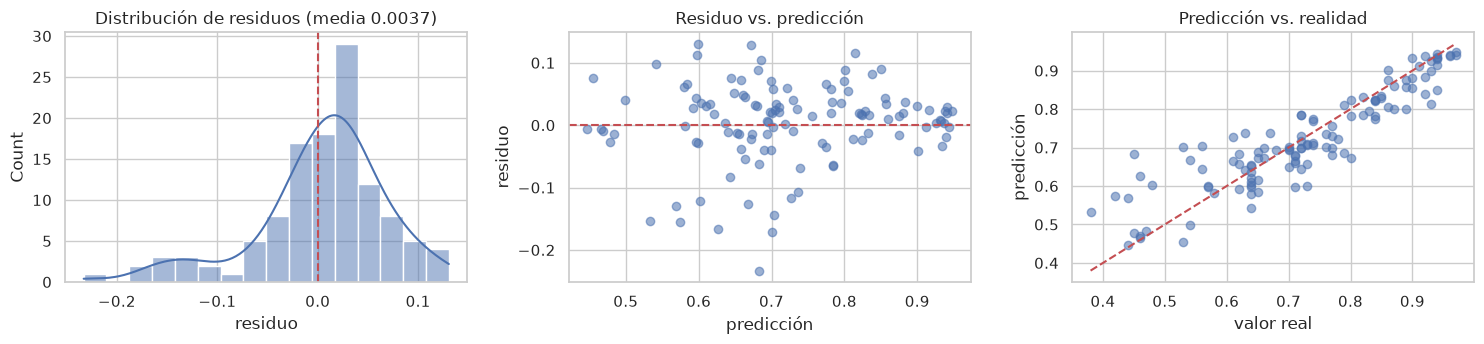

Rango real     : [0.380, 0.970]
Rango predicho : [0.447, 0.948]
Predicciones optimistas: 39.8%
Error medio cuando sobrestima: 0.0552
Error medio cuando subestima : 0.0426


In [12]:
_, axes = plt.subplots(1, 3, figsize=(15, 3.6))
sns.histplot(residuos, kde=True, ax=axes[0])
axes[0].axvline(0, color="r", linestyle="--")
axes[0].set_title(f"Distribución de residuos (media {residuos.mean():.4f})")

axes[1].scatter(prediccion, residuos, alpha=0.55)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("predicción")
axes[1].set_ylabel("residuo")
axes[1].set_title("Residuo vs. predicción")

axes[2].scatter(y_test, prediccion, alpha=0.55)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[2].set_xlabel("valor real")
axes[2].set_ylabel("predicción")
axes[2].set_title("Predicción vs. realidad")
plt.tight_layout()
plt.show()

sobrestima = prediccion > y_test
print(f"Rango real     : [{y_test.min():.3f}, {y_test.max():.3f}]")
print(f"Rango predicho : [{prediccion.min():.3f}, {prediccion.max():.3f}]")
print(f"Predicciones optimistas: {sobrestima.mean():.1%}")
print(f"Error medio cuando sobrestima: {(prediccion - y_test)[sobrestima].mean():.4f}")
print(f"Error medio cuando subestima : {(y_test - prediccion)[~sobrestima].mean():.4f}")

In [13]:
tercil = pd.qcut(y_test, 3, labels=["target bajo", "target medio", "target alto"])
errores_por_tercil = pd.DataFrame(
    {
        "MAE": errores.groupby(tercil, observed=True).mean(),
        "sesgo_medio": residuos.groupby(tercil, observed=True).mean(),
        "n": errores.groupby(tercil, observed=True).size(),
    }
)
print("Sesgo positivo = el modelo se queda corto")
errores_por_tercil.round(4)

Sesgo positivo = el modelo se queda corto


,MAE,sesgo_medio,n
chance_of_admit,,,
target bajo,0.0654,-0.0387,40
target medio,0.0438,0.0246,40
target alto,0.0328,0.0261,38


**El modelo comete tres tipos de error, y solo el primero es grave:**

1. **Compresión del rango.** El modelo predice entre 0.447 y 0.948, mientras los valores
   reales van de 0.38 a 0.97. **No puede predecir por debajo de 0.45**, así que todo
   aspirante con probabilidad real menor recibe una estimación optimista por
   construcción. Es consecuencia directa del aplanamiento visto en las curvas de
   dependencia parcial: un ensamble de árboles promedia valores de hojas y nunca
   extrapola fuera de lo que vio.
2. **Sesgo hacia el centro.** MAE de 0.065 en el tercil bajo frente a 0.033 en el alto: el
   modelo se equivoca **el doble** con los aspirantes de perfil débil. En el tercil bajo
   sobrestima 0.039 de media; en el alto subestima 0.026.
3. **Errores simétricos en el centro.** En el grueso de la distribución los residuos están
   centrados y sin patrón, que es el comportamiento deseable.

Y un detalle que importa para el uso real: cuando el modelo **sobrestima se equivoca más**
(0.055 de media) que cuando subestima (0.043). Sus errores no solo van con más frecuencia
en la dirección optimista en la zona baja, sino que además son mayores.

## 🔬 ¿A qué se deben los errores?

Se revisan una por una las causas candidatas que plantea el enunciado, con datos y no con
suposiciones.

### Candidata 1: ¿valores atípicos?

In [14]:
def marcar_atipicos(serie: pd.Series) -> pd.Series:
    """Marca los valores fuera del rango intercuartílico ampliado 1.5x."""
    numerica = serie.astype(float)
    q1, q3 = numerica.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (numerica < q1 - 1.5 * iqr) | (numerica > q3 + 1.5 * iqr)


atipicos = (
    marcar_atipicos(X_test["cgpa"]) | marcar_atipicos(X_test["lor"]) | marcar_atipicos(y_test)
)
print(f"Filas atipicas en el conjunto de prueba: {int(atipicos.sum())} de {len(X_test)}")
if atipicos.any():
    print(errores.groupby(atipicos).agg(["mean", "size"]).round(4).to_string())
else:
    print("No hay ninguna: los atipicos NO explican los errores.")

Filas atipicas en el conjunto de prueba: 0 de 118
No hay ninguna: los atipicos NO explican los errores.


**Descartada.** No hay ni una sola fila atípica en el conjunto de prueba según el criterio
IQR. Los 4 atípicos que documentó `03.1` en todo el dataset cayeron en entrenamiento y, en
cualquier caso, eran valores dentro del dominio válido.

### Candidata 2: ¿clase desbalanceada?

No aplica literalmente —esto es regresión, no clasificación— pero **sí existe el problema
análogo**: el rango del target está desbalanceado.

Filas de entrenamiento con target < 0.5: 28 de 353 (7.9%)

Distribución del target en entrenamiento:
chance_of_admit
(0.0, 0.5]     31
(0.5, 0.6]     36
(0.6, 0.7]     82
(0.7, 0.8]    103
(0.8, 0.9]     59
(0.9, 1.0]     42


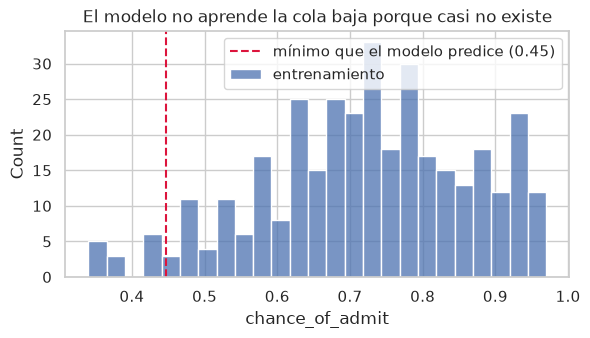

In [15]:
# umbral por debajo del cual el modelo practicamente no tiene ejemplos
UMBRAL_COLA_BAJA = 0.5

distribucion_train = pd.cut(y_train, [0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]).value_counts().sort_index()
cola_baja = y_train < UMBRAL_COLA_BAJA
proporcion_baja = cola_baja.mean()

print(
    f"Filas de entrenamiento con target < {UMBRAL_COLA_BAJA}: {int(cola_baja.sum())} de {len(y_train)} ({proporcion_baja:.1%})"
)
print("\nDistribución del target en entrenamiento:")
print(distribucion_train.to_string())

_, ax = plt.subplots(figsize=(6.5, 3.2))
sns.histplot(y_train, bins=25, ax=ax, label="entrenamiento")
ax.axvline(
    prediccion.min(),
    color="crimson",
    linestyle="--",
    label=f"mínimo que el modelo predice ({prediccion.min():.2f})",
)
ax.set_title("El modelo no aprende la cola baja porque casi no existe")
ax.legend()
plt.show()

**Confirmada, y es la causa del error tipo 1.** Solo el **7.9 %** de las filas de
entrenamiento tiene un target por debajo de 0.5. Un modelo que promedia hojas necesita
ejemplos suficientes en una región para poder predecir en ella; con 28 casos repartidos
entre todos los perfiles posibles, la región baja está infrarrepresentada y el modelo se
queda en 0.45 como suelo.

### Candidata 3: ¿errores en el ingreso de datos?

In [16]:
filas_con_faltantes = X_test.isna().any(axis=1)
errores_por_faltantes = pd.DataFrame(
    {
        "MAE": errores.groupby(filas_con_faltantes).mean(),
        "n": errores.groupby(filas_con_faltantes).size(),
    }
)
errores_por_faltantes.index = ["sin datos faltantes", "con algún dato imputado"]
print(errores_por_faltantes.round(4).to_string())

incremento = (
    errores_por_faltantes.loc["con algún dato imputado", "MAE"]
    / errores_por_faltantes.loc["sin datos faltantes", "MAE"]
    - 1
)
print(f"\nIncremento del error en filas imputadas: {incremento:.1%}")

                            MAE   n
sin datos faltantes      0.0465  93
con algún dato imputado  0.0515  25

Incremento del error en filas imputadas: 10.6%


**Contribución menor.** Las 25 filas con algún dato imputado tienen un MAE de 0.0515
frente a 0.0465 de las completas: un 11 % más de error. Es coherente —una mediana
imputada aporta menos información que el dato real— pero con 25 filas la diferencia está
dentro de lo esperable por azar, y de todas formas no explica los errores grandes.

No se detectaron valores fuera del dominio documentado en ninguna etapa del proyecto
(`02-exploration` lo verificó), así que **errores de captura propiamente dichos no hay**.

### Candidata 4: ¿la codificación de variables?

In [17]:
errores_por_rating = pd.DataFrame(
    {
        "MAE": errores.groupby(
            X_test["university_rating"].astype("string").fillna("faltante"), observed=True
        ).mean(),
        "n": errores.groupby(
            X_test["university_rating"].astype("string").fillna("faltante"), observed=True
        ).size(),
    }
)
errores_por_research = pd.DataFrame(
    {
        "MAE": errores.groupby(
            X_test["research"].astype("string").fillna("faltante"), observed=True
        ).mean(),
        "n": errores.groupby(
            X_test["research"].astype("string").fillna("faltante"), observed=True
        ).size(),
    }
)
print("Error por university_rating (codificado como ordinal):")
print(errores_por_rating.round(4).to_string())
print("\nError por research (codificado como 0/1):")
print(errores_por_research.round(4).to_string())

Error por university_rating (codificado como ordinal):
                      MAE   n
university_rating            
1                  0.0055   1
2                  0.0505  39
3                  0.0593  36
4                  0.0326  22
5                  0.0357  18
faltante           0.0731   2

Error por research (codificado como 0/1):
             MAE   n
research            
False     0.0594  48
True      0.0408  59
faltante  0.0322  11


**Descartada.** Si la codificación ordinal de `university_rating` fuera el problema, el
error crecería de forma sistemática hacia un extremo de la escala — la señal típica de
imponer un orden o una distancia equivocada. No ocurre: el error sube en los niveles 2 y 3
(0.051 y 0.059) y baja en el 4 y el 5 (0.033 y 0.036), un patrón que sigue al **volumen de
datos por nivel**, no al orden de la escala.

En `research` el error es mayor cuando vale `False` (0.059) que cuando vale `True` (0.041),
lo que de nuevo apunta al mismo sitio: los aspirantes sin investigación se concentran en la
parte baja del target, que es donde el modelo falla.

### Candidata 5: ¿ruido en la propia variable objetivo?

Esta es la hipótesis que ninguna de las anteriores explica, y la que el caso del peor error
sugería. Se puede medir: si se toman los **5 aspirantes de entrenamiento con el perfil más
parecido** a cada aspirante de prueba, ¿cuánto difieren *entre sí* sus targets? Esa
dispersión es un piso: ningún modelo que use solo estas siete variables puede bajar de ahí,
porque perfiles idénticos tienen resultados distintos.

Dispersión del target entre perfiles casi idénticos: 0.0484
MAE del modelo                                     : 0.0476
Correlación entre el error y la dispersión local   : 0.272

MAE donde el target es inconsistente: 0.0608
MAE donde el target es consistente  : 0.0344


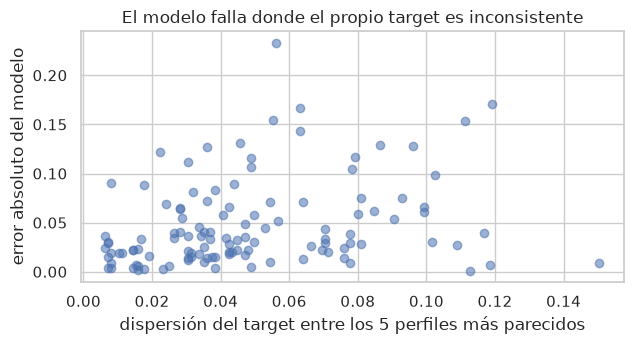

In [18]:
vecinos = NearestNeighbors(n_neighbors=5).fit(X_train_preparado.to_numpy())
_, indices_vecinos = vecinos.kneighbors(X_test_preparado.to_numpy())

objetivo_train = y_train.to_numpy()
dispersion_local = np.array(
    [np.abs(objetivo_train[fila] - objetivo_train[fila].mean()).mean() for fila in indices_vecinos]
)

mae_modelo = errores.mean()
print(f"Dispersión del target entre perfiles casi idénticos: {dispersion_local.mean():.4f}")
print(f"MAE del modelo                                     : {mae_modelo:.4f}")
print(
    f"Correlación entre el error y la dispersión local   : {np.corrcoef(errores, dispersion_local)[0, 1]:.3f}"
)

dispersion_alta = dispersion_local > np.median(dispersion_local)
print(f"\nMAE donde el target es inconsistente: {errores[dispersion_alta].mean():.4f}")
print(f"MAE donde el target es consistente  : {errores[~dispersion_alta].mean():.4f}")

_, ax = plt.subplots(figsize=(6.5, 3.6))
ax.scatter(dispersion_local, errores, alpha=0.55)
ax.set_xlabel("dispersión del target entre los 5 perfiles más parecidos")
ax.set_ylabel("error absoluto del modelo")
ax.set_title("El modelo falla donde el propio target es inconsistente")
plt.tight_layout()
plt.show()

**Confirmada, y es la causa dominante.**

Dos aspirantes con perfiles prácticamente idénticos difieren en **0.0484** de probabilidad
de admisión, en promedio. El MAE del modelo es **0.0476**. Es decir: **el modelo ya se
equivoca menos de lo que el propio target se contradice a sí mismo**.

Y la relación se sostiene punto por punto: donde el target es inconsistente el modelo tiene
un MAE de 0.0608; donde es consistente, de 0.034 — casi la mitad. La correlación entre el
error del modelo y la dispersión local es 0.27.

Tiene una explicación de fondo, ya anticipada en `notebooks/1-data`: `chance_of_admit` **no
es un hecho observado, es una probabilidad estimada** por alguien. Toda la subjetividad de
esa estimación está dentro de los datos, y ningún modelo puede predecir lo que es
arbitrario.

### Resumen de causas

| Causa candidata | Veredicto | Evidencia |
|---|---|---|
| Valores atípicos | ❌ Descartada | 0 filas atípicas en el conjunto de prueba |
| Clase / rango desbalanceado | ✅ **Confirmada** | solo 7.9 % del entrenamiento por debajo de 0.5; el modelo no predice bajo 0.45 |
| Errores de ingreso de datos | ❌ Descartada | ningún valor fuera del dominio documentado |
| Datos faltantes / imputación | ⚠️ Menor | +11 % de error en 25 filas imputadas |
| Codificación (*encoders*) | ❌ Descartada | el error no sigue el orden de la escala, sigue al volumen de datos |
| **Ruido del target** | ✅ **Dominante** | dispersión local 0.0484 vs. MAE 0.0476 |

## ⚠️ ¿Cuáles son las consecuencias de las malas predicciones?

Un error de 0.05 en una probabilidad no significa nada por sí solo: hay que traducirlo a lo
que le pasa a la persona que usa el producto. El uso definido en `notebooks/1-data` es
ordenar universidades en tres cestas —**segura / probable / ambiciosa**— para que el
aspirante arme su lista de postulaciones.

Los dos errores posibles **no cuestan lo mismo**:

| Error | Qué le pasa al aspirante | Costo |
|---|---|---|
| **Optimista** (predice más de lo real) | postula solo a universidades que cree seguras y **se queda sin admisión** | Alto: pierde un ciclo completo, con sus tasas de postulación y su tiempo |
| **Pesimista** (predice menos de lo real) | descarta universidades a las que sí habría entrado | Moderado: pierde una oportunidad, pero entra en otra parte |

La asimetría es clara, y hay un dato incómodo: el modelo **sobrestima con más frecuencia y
con más magnitud justo en el tramo bajo**, que es donde el error optimista hace daño.

Cortes aprendidos en entrenamiento: [0.67, 0.79]
Acierto de cesta del modelo final : 79.7%
Acierto de cesta del modelo base  : 68.6%   (azar: 33.3%)

Errores graves optimistas (ambiciosa -> segura): 0
Errores graves pesimistas (segura -> ambiciosa): 0


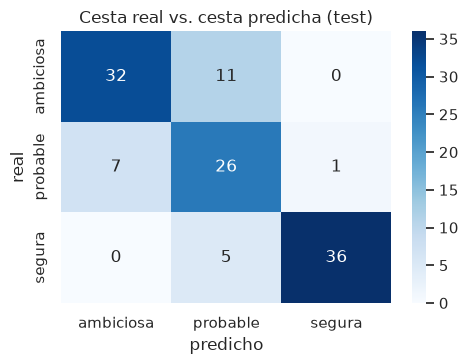

predicho,ambiciosa,probable,segura
real,,,
ambiciosa,32,11,0
probable,7,26,1
segura,0,5,36


In [19]:
cortes = y_train.quantile([1 / 3, 2 / 3]).tolist()
ETIQUETAS = ["ambiciosa", "probable", "segura"]

cesta_real = pd.cut(y_test, [-np.inf, *cortes, np.inf], labels=ETIQUETAS)
cesta_predicha = pd.cut(prediccion, [-np.inf, *cortes, np.inf], labels=ETIQUETAS)

matriz = pd.crosstab(cesta_real, cesta_predicha, rownames=["real"], colnames=["predicho"])
acierto = float((cesta_real == cesta_predicha).mean())

modelo_base = joblib.load(ARCHIVO_MODELO_BASE)
cesta_base = pd.cut(
    pd.Series(modelo_base.predict(X_test), index=X_test.index),
    [-np.inf, *cortes, np.inf],
    labels=ETIQUETAS,
)
acierto_base = float((cesta_real == cesta_base).mean())

print(f"Cortes aprendidos en entrenamiento: {[round(c, 3) for c in cortes]}")
print(f"Acierto de cesta del modelo final : {acierto:.1%}")
print(f"Acierto de cesta del modelo base  : {acierto_base:.1%}   (azar: 33.3%)")
print(
    f"\nErrores graves optimistas (ambiciosa -> segura): {int(matriz.loc['ambiciosa', 'segura'])}"
)
print(f"Errores graves pesimistas (segura -> ambiciosa): {int(matriz.loc['segura', 'ambiciosa'])}")

_, ax = plt.subplots(figsize=(5, 3.8))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Cesta real vs. cesta predicha (test)")
plt.tight_layout()
plt.show()
matriz

**En el uso real, las consecuencias son moderadas y mejoran claramente al modelo base:**

- **79.7 % de acierto de cesta**, frente al 68.6 % del modelo base y al 33 % del azar.
- **Cero errores graves en ambas direcciones.** Ni un solo aspirante de cesta "ambiciosa"
  fue clasificado como "segura", que es el fallo con consecuencias reales. Todos los
  errores son de una cesta adyacente.
- Los 11 casos de "ambiciosa" clasificados como "probable" son el grupo a vigilar: no es un
  error catastrófico, pero empuja en la dirección optimista.

**La conclusión operativa** es que el modelo se puede usar para recomendar, con una
salvaguarda: dado que no predice por debajo de 0.45 y que sobrestima en el tramo bajo, la
interfaz **no debería mostrar el número desnudo** a los aspirantes de perfil débil, sino un
rango o una advertencia explícita. El modelo es fiable ordenando; es menos fiable dando la
cifra exacta en el extremo bajo.

## 🧪 Pruebas y experimentos para la siguiente iteración

Este es el entregable principal del notebook. Cada experimento sale de una evidencia
concreta de las secciones anteriores, tiene una hipótesis falsable y un criterio de éxito
definido **antes** de ejecutarlo — de otro modo siempre se encuentra la manera de declarar
victoria.

Referencia actual a superar: **MAE 0.0476**, acierto de cesta **79.7 %**.

### Prioridad alta

| # | Experimento | Evidencia que lo motiva | Hipótesis | Criterio de éxito |
|---|---|---|---|---|
| 1 | **Ponderar las muestras del tramo bajo** (`sample_weight` inversamente proporcional a la densidad del target) | solo 7.9 % del entrenamiento está bajo 0.5 y el modelo no predice bajo 0.45 | corregir el desbalance del rango reduce el sesgo optimista sin degradar el resto | MAE del tercil bajo < 0.055 (hoy 0.065) sin que el MAE global suba más de 0.002 |
| 2 | **Intervalos de predicción** en vez de un número: usar la dispersión entre árboles o un `GradientBoosting` cuantílico | el error se concentra donde el target es inconsistente (dispersión 0.048) | mostrar un rango comunica la incertidumbre real y evita el falso sesgo de precisión | cobertura empírica del intervalo al 80 % entre 75 % y 85 % |
| 3 | **Ensamblar `Ridge` + Extra Trees** (promedio o *stacking*) | perfiles de error opuestos: sesgo alto / varianza alta | la combinación reduce el error donde cada uno falla | MAE < 0.0458 (mejora de al menos una desviación estándar) |
| 4 | **Validar el techo con datos nuevos**: recoger más filas, sobre todo de perfil bajo | la curva de aprendizaje **sigue bajando** en el último punto | el modelo aún no ha saturado; más datos mejoran | MAE < 0.045 con un 25 % más de filas |

### Prioridad media

| # | Experimento | Evidencia que lo motiva | Hipótesis | Criterio de éxito |
|---|---|---|---|---|
| 5 | **Optimizar directamente el acierto de cesta** en vez del MAE | el uso real es ordenar, no dar la cifra exacta | una métrica alineada con el uso mejora lo que importa | acierto de cesta > 82 % sin que el MAE suba más de 0.003 |
| 6 | **Imputación por modelo** (`IterativeImputer`) en lugar de la mediana | las filas imputadas tienen un 11 % más de error | aprovechar la correlación entre atributos mejora la imputación | MAE de las filas con faltantes < 0.048 (hoy 0.0515) |
| 7 | **Modelo monótono** (`HistGradientBoosting` con `monotonic_cst`) | las curvas de dependencia parcial ya son monótonas | imponer la monotonía no cuesta desempeño y hace el modelo defendible ante un usuario | MAE dentro de ±0.002 del actual |
| 8 | **Repetir el AutoML con más presupuesto y sin restringir familias** | la búsqueda de `06` duró 180 s y el ajuste fino no aportó | con más presupuesto puede aparecer una familia mejor | MAE < 0.0458 |

### Prioridad baja / exploratorio

| # | Experimento | Evidencia que lo motiva | Hipótesis | Criterio de éxito |
|---|---|---|---|---|
| 9 | **Cuantificar el ruido del target** con un segundo evaluador o una fuente externa | el modelo ya está en el nivel de ruido del target | el techo real está en la calidad del target, no en el modelo | estimar el error irreducible con un intervalo de confianza |
| 10 | **Eliminar `sop` y `lor`** del modelo | aportan un 6 % y 7 % de SHAP y son autoevaluaciones subjetivas | un modelo con 5 atributos es más barato de mantener y casi igual de bueno | MAE dentro de ±0.002 con dos atributos menos |
| 11 | **Probar `TabPFN`** | es un modelo preentrenado diseñado para datasets tabulares pequeños, que es exactamente este caso | puede superar al ensamble sin ajuste | MAE < 0.0458 |
| 12 | **Análisis de equidad por `university_rating`** | el error varía entre niveles (0.033 a 0.059) | el modelo puede estar sistemáticamente peor con aspirantes de universidades de rating medio | diferencia de MAE entre niveles < 0.02 |

**Lo que NO conviene probar, y por qué:** más ingeniería de atributos sobre las siete
variables actuales. `04-feat_eng` ya midió atributos derivados, discretización y
transformaciones no lineales, y ninguno mejoró; y este notebook muestra que el modelo ya
está en el nivel de ruido del target. Insistir por ahí es gastar esfuerzo en la parte del
problema que ya está resuelta.

## 💾 Guardar los resultados de la interpretación

El modelo `.joblib` **no se modifica**: este notebook interpreta el artefacto que ya quedó
versionado en `06` (`data/06_models/modelo_final_automl.joblib`), y volver a exportarlo solo
crearía una copia divergente. Lo que sí se guarda son las tablas de interpretación, para
que el plan de experimentos pueda compararse contra ellas en la siguiente iteración.

In [20]:
comparacion_importancias.reset_index(names="atributo").to_parquet(
    DIR_REPORTES / "importancia_atributos.parquet", index=False
)

resumen_errores = pd.concat(
    [
        errores_por_tercil.assign(segmento="tercil del target").rename_axis("grupo").reset_index(),
        errores_por_faltantes.assign(segmento="datos faltantes").rename_axis("grupo").reset_index(),
        errores_por_rating.assign(segmento="university_rating").rename_axis("grupo").reset_index(),
        errores_por_research.assign(segmento="research").rename_axis("grupo").reset_index(),
    ],
    ignore_index=True,
)
resumen_errores["grupo"] = resumen_errores["grupo"].astype(str)
resumen_errores.to_parquet(DIR_REPORTES / "errores_por_segmento.parquet", index=False)

diagnostico = pd.DataFrame(
    [
        {"indicador": "MAE en test", "valor": mae_modelo},
        {
            "indicador": "dispersion local del target (piso estimado)",
            "valor": dispersion_local.mean(),
        },
        {"indicador": "acierto de cesta", "valor": acierto},
        {"indicador": "prediccion minima posible", "valor": float(prediccion.min())},
        {"indicador": "proporcion de train con target < 0.5", "valor": float(proporcion_baja)},
    ]
)
diagnostico.to_parquet(DIR_REPORTES / "diagnostico_modelo.parquet", index=False)

for archivo in ("importancia_atributos", "errores_por_segmento", "diagnostico_modelo"):
    print(f"guardado -> data/08_reporting/{archivo}.parquet")
print()
diagnostico.round(4)

guardado -> data/08_reporting/importancia_atributos.parquet
guardado -> data/08_reporting/errores_por_segmento.parquet
guardado -> data/08_reporting/diagnostico_modelo.parquet



,indicador,valor
0,MAE en test,0.0476
1,dispersion local del target (piso estimado),0.0484
2,acierto de cesta,0.7966
3,prediccion minima posible,0.4469
4,proporcion de train con target < 0.5,0.0793


## 📊 Analysis of Results and Conclusions

**Cómo decide el modelo.** `cgpa` domina (30 % de la importancia SHAP), seguido de
`gre_score` (19 %) y `toefl_score` (15 %). Todos los atributos empujan en la dirección
esperada —valores altos suben la predicción— y las curvas ICE son casi paralelas, lo que
significa que el modelo se comporta **casi como un modelo aditivo**: hay pocas
interacciones fuertes. Eso explica por qué la `Ridge` de `04` se quedaba a solo 0.0018 de
MAE del ensamble de árboles.

**Los tres métodos de importancia discrepan en `research`**, y la discrepancia es
informativa, no un error: SHAP le da un 14 % y la permutación casi nada, porque la
permutación mide *información única* y `research` está duplicada en `university_rating` y
en el bloque académico. Es informativa pero redundante.

**Qué errores comete.** Comprime el rango (predice entre 0.447 y 0.948 cuando la realidad
va de 0.38 a 0.97), se sesga hacia el centro —MAE del 0.065 en el tercil bajo frente a
0.033 en el alto— y cuando sobrestima se equivoca más (0.055) que cuando subestima
(0.043).

**A qué se deben.** Se descartaron con datos los atípicos, los errores de captura y la
codificación. Quedan dos causas reales: el **desbalance del rango del target** (solo 7.9 %
del entrenamiento por debajo de 0.5, lo que impide al modelo predecir ahí) y, sobre todo,
el **ruido del propio target**: dos aspirantes con perfiles casi idénticos difieren en
0.0484 de probabilidad, y el MAE del modelo es 0.0476. **El modelo ya se equivoca menos de
lo que el target se contradice a sí mismo.**

Esa última frase es la conclusión más importante del notebook, porque cambia dónde hay que
invertir: no en modelos mejores, sino en un target más fiable o en variables nuevas.

**Consecuencias.** En el uso real —clasificar universidades en segura / probable /
ambiciosa— el modelo acierta el **79.7 %** frente al 68.6 % del modelo base, y comete
**cero errores graves**. Es utilizable para recomendar, con la salvaguarda de no mostrar la
cifra desnuda a los aspirantes de perfil bajo, donde sobrestima por construcción.

**El plan de experimentos** de la sección anterior recoge 12 pruebas priorizadas, cada una
con su hipótesis y su criterio de éxito fijado de antemano. Las cuatro de prioridad alta
atacan directamente las dos causas de error identificadas.

## 💡 Proposals and Ideas

- **Documentar el suelo de error en la ficha del modelo.** Que el MAE esté en 0.0476 y el
  ruido del target en 0.0484 debería estar escrito donde lo vea quien proponga el siguiente
  modelo, para que nadie invierta semanas en arañar milésimas imposibles.
- **Mostrar la explicación SHAP al usuario final.** El gráfico de cascada de este notebook
  es directamente traducible a "tu promedio suma 0.08, tu GRE suma 0.03, no tener
  investigación te resta 0.04". En un producto de orientación, eso vale más que el número.
- **Añadir una advertencia automática** cuando la predicción caiga por debajo de 0.55: es la
  zona donde el modelo sobrestima y donde el error es el doble.
- **Monitorizar en producción la dispersión local**: si llegan aspirantes cuyos vecinos más
  cercanos en entrenamiento están lejos, la predicción es menos fiable y conviene señalarlo.
- **Revisar el origen del target antes de la siguiente iteración.** Es la vía con más
  recorrido: mientras `chance_of_admit` sea una estimación subjetiva, el techo del proyecto
  lo pone quien la estimó, no el modelo.

## 📖 References

- Interpretación de modelos, Jose R. Zapata:
  <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/7-model_interpretation/>
- SHAP: <https://shap.readthedocs.io/>
- Importancia por permutación y sus limitaciones con atributos correlacionados:
  <https://scikit-learn.org/stable/modules/permutation_importance.html>
- Dependencia parcial e ICE:
  <https://scikit-learn.org/stable/modules/partial_dependence.html>
- Modelo interpretado: `data/06_models/modelo_final_automl.joblib` (PR de `06-models`)